<a href="https://colab.research.google.com/github/dinda-dwi-lestari/Matematika-Aktuaria/blob/main/projek_aktuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   age  gender region income_level  hypertension  diabetes  cholesterol_level  \
0   60    Male  Rural       Middle             0         1                211   
1   53  Female  Urban          Low             0         0                208   
2   62  Female  Urban          Low             0         0                231   
3   73    Male  Urban          Low             1         0                202   
4   52    Male  Urban       Middle             1         0                232   

   obesity  waist_circumference  family_history  ... blood_pressure_diastolic  \
0        0                   83               0  ...                       62   
1        0                  106               1  ...                       76   
2        1                  112               1  ...                       74   
3        0                   82               1  ...                       65   
4        0                   89               0  ...                       75   

  fasting_blood_sugar chol

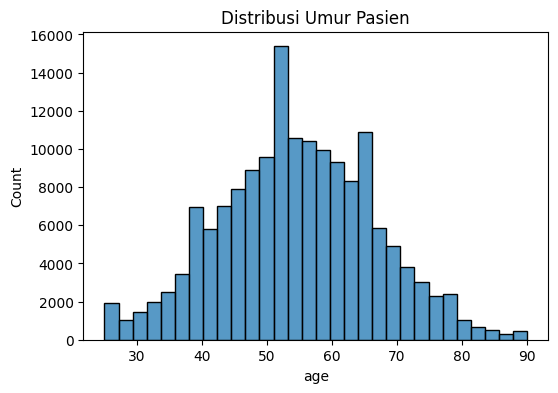

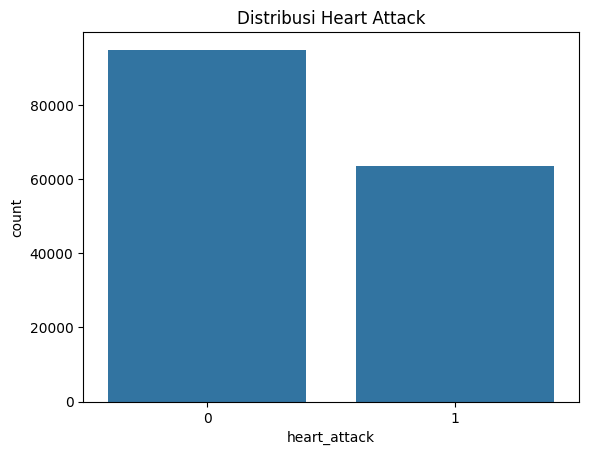

ValueError: could not convert string to float: 'Rural'

<Figure size 1000x800 with 0 Axes>

In [11]:
# ===============================
# IMPORT LIBRARY
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

# ===============================
# LOAD DATASET
# ===============================

data = pd.read_csv("/content/67f1668b760f5.csv")

# melihat 5 data pertama
print(data.head())

# melihat struktur data
print(data.info())

# melihat ukuran data
print(data.shape)

# ===============================
# DATA CLEANING
# ===============================

# cek missing value
print(data.isnull().sum())

# ubah gender menjadi numerik
data['gender'] = data['gender'].map({
    'Male':1,
    'Female':0
})

# ubah smoking status
data['smoking_status'] = data['smoking_status'].map({
    'Never':0,
    'Former':1,
    'Current':2
})

# cek ulang
print(data.head())

# ===============================
# EXPLORATORY DATA ANALYSIS
# ===============================

# distribusi umur
plt.figure(figsize=(6,4))
sns.histplot(data['age'], bins=30)
plt.title("Distribusi Umur Pasien")
plt.show()

# jumlah serangan jantung
sns.countplot(x='heart_attack', data=data)
plt.title("Distribusi Heart Attack")
plt.show()

# korelasi
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ===============================
# SURVIVAL BERDASARKAN GENDER
# ===============================

male = data[data['gender'] == 1]
female = data[data['gender'] == 0]
kmf = KaplanMeierFitter()
kmf.fit(male['age'], male['heart_attack'], label="Male")
ax = kmf.plot()

kmf.fit(female['age'], female['heart_attack'], label="Female")
kmf.plot(ax=ax)

plt.title("Survival Curve Berdasarkan Gender")
plt.xlabel("Usia")
plt.ylabel("Probabilitas Bertahan Hidup")
plt.show()

# ===============================
# COX PROPORTIONAL HAZARD MODEL
# ===============================

cox_data = data[[
    'age',
    'gender',
    'hypertension',
    'diabetes',
    'obesity',
    'smoking_status',
    'cholesterol_ldl',
    'blood_pressure_systolic',
    'heart_attack'
]]

cph = CoxPHFitter()

cph.fit(cox_data,
        duration_col='age',
        event_col='heart_attack')

cph.print_summary()

# ===============================
# PLOT HAZARD RATIO
# ===============================

cph.plot()
plt.title("Hazard Ratio Variabel Risiko")
plt.show()

# ===============================
# TABEL MORTALITAS
# ===============================


life_table = data.groupby("age").agg(
    total_population=('heart_attack', 'count'),
    deaths=('heart_attack', 'sum')
).reset_index()

# urutkan berdasarkan usia
life_table = life_table.sort_values(by="age")

# probabilitas kematian
life_table['qx'] = life_table['deaths'] / life_table['total_population']

# ganti NaN jika ada
life_table['qx'] = life_table['qx'].fillna(0)

# tampilkan 5 data pertama
print(life_table.head())




# ===============================
# SAVE RESULT
# ===============================

life_table.to_csv("tabel_mortalitas.csv")



In [4]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=be4e2a4b6e8932e0b6f790c10c20a2f7581ed7321d20c82b324f3255919b0385
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
